For unsupervised machine learning in Python, the most commonly used package is scikit-learn (sklearn). Here are a few key algorithms it provides for unsupervised learning:

📌 Clustering Algorithms
K-Means: sklearn.cluster.KMeans
DBSCAN: sklearn.cluster.DBSCAN
Agglomerative Clustering: sklearn.cluster.AgglomerativeClustering
Mean Shift: sklearn.cluster.MeanShift
Spectral Clustering: sklearn.cluster.SpectralClustering


📌 Dimensionality Reduction
Principal Component Analysis (PCA): sklearn.decomposition.PCA
t-SNE (t-Distributed Stochastic Neighbor Embedding): sklearn.manifold.TSNE
UMAP (from umap-learn package): umap.UMAP()


📌 Anomaly Detection
Isolation Forest: sklearn.ensemble.IsolationForest
One-Class SVM: sklearn.svm.OneClassSVM
LOF (Local Outlier Factor): sklearn.neighbors.LocalOutlierFactor


📌 Other Useful Libraries
SciPy (scipy.cluster.hierarchy) → For hierarchical clustering
HDBSCAN (hdbscan) → More advanced clustering than DBSCAN
To install the necessary packages if you haven't already:

bash
Copy
Edit
pip install scikit-learn umap-learn hdbscan
Would you like help implementing a specific algorithm? 🚀

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from yfinance import ticker

In [2]:
#np.random.seed(42)
#X = np.random.rand(100, 2) * 100
#X[0:3]

In [3]:
data = pd.read_csv('stock_and_info.csv')
data = data.replace([np.inf, -np.inf], 999)
data = data[data['score'] <= 100]
data['sector_n'] = pd.factorize(data['sector'])[0]
data['industry_n'] = pd.factorize(data['industry'])[0]

X = data[['score', 'industry_n']].to_numpy()
#X = np.array(data['score'], data['weight'])

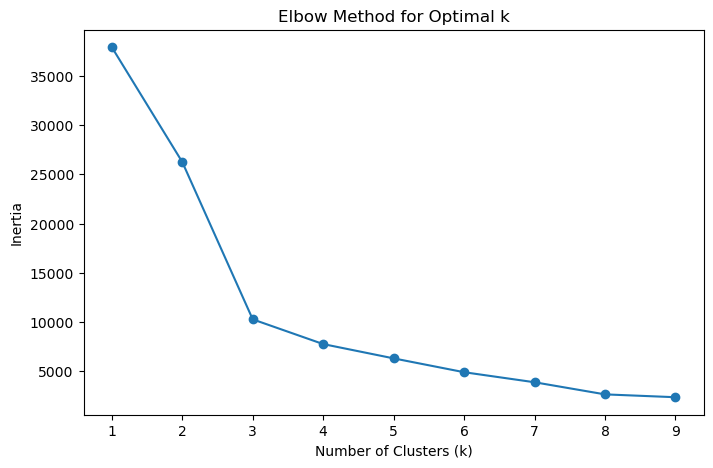

In [4]:
#Find the Optimal k using the Elbow Method (Optional)
inertia = []
K_range = range(1, 10)  # Try different cluster numbers

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)  # Inertia measures clustering quality

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [5]:
k = 3  # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)

KMeans(n_clusters=3, random_state=42)

In [6]:
labels = kmeans.labels_  # Cluster assignments for each point
centroids = kmeans.cluster_centers_

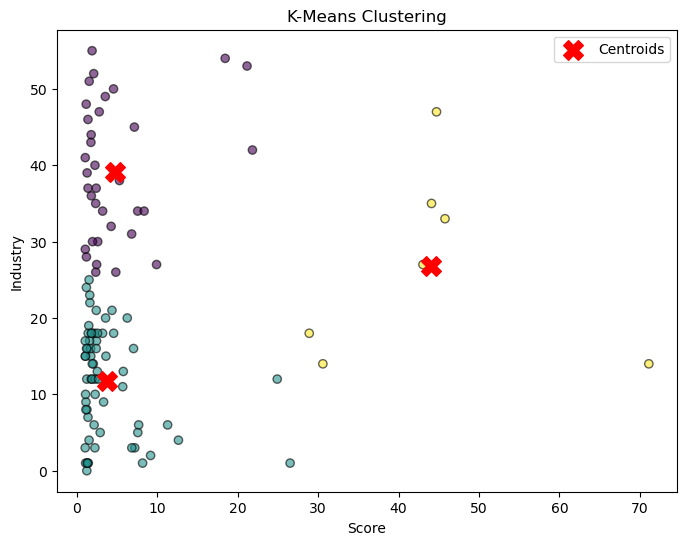

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6, edgecolors='k')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.xlabel("Score")
plt.ylabel("Industry")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

In [8]:
data['i_cluster'] = labels
data.head()

,Unnamed: 0,ticker,sector,industry,min_val,max_val,current_value,score,weight,weighted_score,divs,sector_n,industry_n,i_cluster
0,0,ADBE,Information Technology,Application Software,275.200012,688.369995,460.160004,1.233834,413.169983,0.002986,True,0,0,1
1,1,AMD,Information Technology,Semiconductors,38.709999,211.380005,113.099998,1.321145,172.670006,0.007651,False,0,1,1
2,2,AES,Utilities,Independent Power Producers & Energy Traders,8.089493,26.797682,9.930000,9.164690,18.708189,0.489876,True,1,2,1
3,3,ALB,Materials,Specialty Chemicals,48.421322,317.137085,81.209999,7.195383,268.715763,0.026777,True,2,3,1
4,4,ARE,Real Estate,Office REITs,86.687798,197.903793,94.849998,12.625736,111.215996,0.113524,True,3,4,1


In [9]:
i_cluster0 = data[data['i_cluster'] == 0]
i_cluster1 = data[data['i_cluster'] == 1]
i_cluster2 = data[data['i_cluster'] == 2]

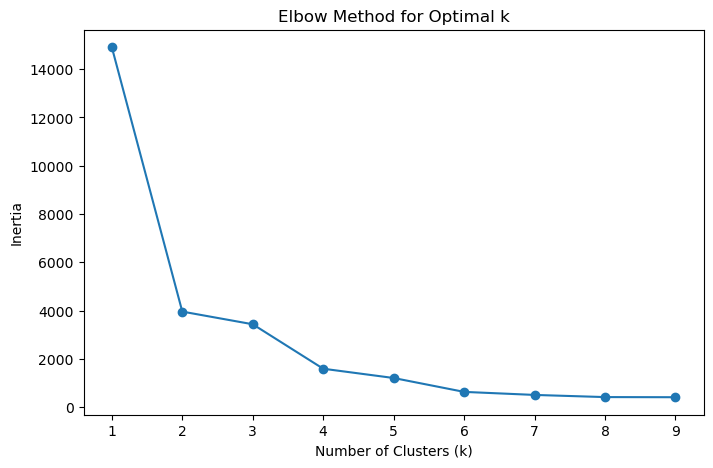

In [10]:
X_sector = data[['score', 'sector_n']].to_numpy()

#Find the Optimal k using the Elbow Method (Optional)
inertia = []
K_range = range(1, 10)  # Try different cluster numbers

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_sector)
    inertia.append(kmeans.inertia_)  # Inertia measures clustering quality

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

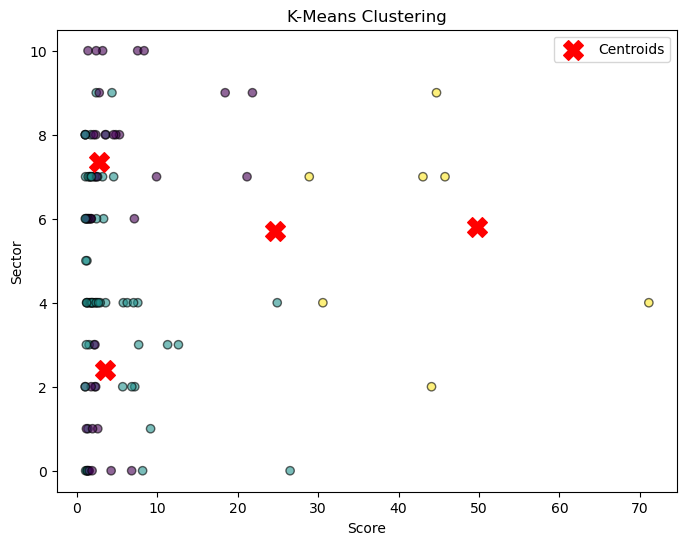

In [11]:
k = 4  # Number of clusters
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_sector)

labels_s = kmeans.labels_  # Cluster assignments for each point
centroids = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))
plt.scatter(X_sector[:, 0], X_sector[:, 1], c=labels, cmap='viridis', alpha=0.6, edgecolors='k')
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.xlabel("Score")
plt.ylabel("Sector")
plt.title("K-Means Clustering")
plt.legend()
plt.show()

In [12]:
data['s_cluster'] = labels_s
data.head()

,Unnamed: 0,ticker,sector,industry,min_val,max_val,current_value,score,weight,weighted_score,divs,sector_n,industry_n,i_cluster,s_cluster
0,0,ADBE,Information Technology,Application Software,275.200012,688.369995,460.160004,1.233834,413.169983,0.002986,True,0,0,1,0
1,1,AMD,Information Technology,Semiconductors,38.709999,211.380005,113.099998,1.321145,172.670006,0.007651,False,0,1,1,0
2,2,AES,Utilities,Independent Power Producers & Energy Traders,8.089493,26.797682,9.930000,9.164690,18.708189,0.489876,True,1,2,1,0
3,3,ALB,Materials,Specialty Chemicals,48.421322,317.137085,81.209999,7.195383,268.715763,0.026777,True,2,3,1,0
4,4,ARE,Real Estate,Office REITs,86.687798,197.903793,94.849998,12.625736,111.215996,0.113524,True,3,4,1,0


In [13]:
s_cluster0 = data[data['s_cluster'] == 0]
s_cluster1 = data[data['s_cluster'] == 1]
s_cluster2 = data[data['s_cluster'] == 2]
s_cluster3 = data[data['s_cluster'] == 3]

In [15]:
s_cluster3

,Unnamed: 0,ticker,sector,industry,min_val,max_val,current_value,score,weight,weighted_score,divs,sector_n,industry_n,i_cluster,s_cluster
12,12,BAX,Health Care,Health Care Equipment,28.629999,85.377892,30.820000,24.912273,56.747892,0.438999,True,4,12,1,3
59,59,HRL,Consumer Staples,Packaged Foods & Meats,27.701401,50.378139,28.459999,28.892946,22.676739,1.274123,True,7,18,2,3
71,71,MTCH,Communication Services,Interactive Media & Services,28.284594,174.509476,34.689999,21.828358,146.224882,0.149279,True,9,42,0,3
74,74,MRNA,Health Care,Biotechnology,18.230000,484.470001,32.990002,30.588071,466.240002,0.065606,False,4,14,2,3
90,90,SWKS,Information Technology,Semiconductors,61.502335,183.323425,65.930000,26.513615,121.821091,0.217644,True,0,1,1,3
101,101,WBA,Consumer Staples,Drug Retail,8.006781,45.523369,9.700000,21.156959,37.516588,0.563936,True,7,53,0,3
103,103,WBD,Communication Services,Broadcasting,6.710000,77.269997,10.340000,18.438015,70.559997,0.261310,False,9,54,0,3
